In [9]:
import os
import random
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import shutup

In [11]:
shutup.please()

model = YOLO("yolov8n.pt")

model.train(
    data="default.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    workers=0,
    device=0,
    verbose=True
)

Ultralytics 8.4.45  Python-3.10.10 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=default.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001CA4EB28D90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [3]:
best_model = YOLO("runs/detect/train-4/weights/best.pt")
metrics = best_model.val()
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")

Ultralytics 8.4.45  Python-3.10.10 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1960.4283.2 MB/s, size: 3255.8 KB)
val: Scanning archive\img.cache... 616 images, 6 backgrounds, 3 corrupt: 100% ━━━━━━━━━━━━ 620/620  0.0s
val: archive\img\GBG_557.jpg: ignoring corrupt image/label: [Errno 2] No such file or directory: 'archive\\img\\GBG_557.jpg'
val: archive\img\GBG_736 (2).jpg: ignoring corrupt image/label: [Errno 2] No such file or directory: 'archive\\img\\GBG_736 (2).jpg'
val: archive\img\GBG_892.jpg: ignoring corrupt image/label: [Errno 2] No such file or directory: 'archive\\img\\GBG_892.jpg'
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 2.0it/s 19.7s0.2s
                   all        617       3279      0.984      0.977       0.99      0.811
Speed: 1.2ms preprocess, 5.0ms in


image 1/1 C:\Users\user\Desktop\study\2 year\4_sem\ai\Planes\archive\img\AMST_039.jpg: 384x640 19 airplanes, 93.2ms
Speed: 5.9ms preprocess, 93.2ms inference, 8.7ms postprocess per image at shape (1, 3, 384, 640)


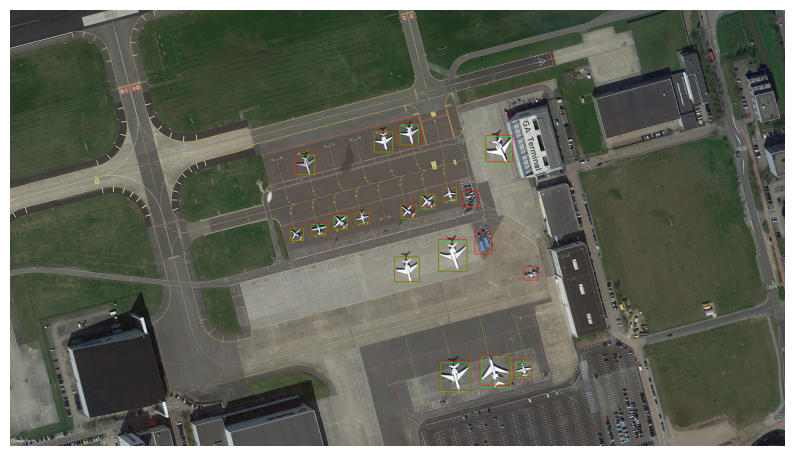

In [12]:
%matplotlib inline
img_path = 'archive/img/AMST_039.jpg'
label_path = 'archive/img/AMST_039.txt'

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w, _ = img.shape

def draw_true_boxes(img, label_path):
    if not os.path.exists(label_path):
        return img

    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:
        cls, x, y, bw, bh = map(float, line.split())

        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    return img

def draw_pred_boxes(img, results):
    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    return img

results = best_model(img_path, conf=0.3)

img_vis = img.copy()

img_vis = draw_true_boxes(img_vis, label_path)
img_vis = draw_pred_boxes(img_vis, results)

plt.figure(figsize=(10, 10))
plt.imshow(img_vis)
plt.axis("off")
plt.show()